In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
import optuna

from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,roc_curve,f1_score
from xgboost import XGBClassifier,callback

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [3]:
test_id = test['id']

In [4]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
train_cols = train.select_dtypes(['object']).columns
test_cols = test.select_dtypes(['object']).columns

In [6]:
train = pd.get_dummies(data=train,columns=train_cols[:-1],drop_first=True,dtype=int)
test = pd.get_dummies(data=test,columns=test_cols,drop_first=True,dtype=int)

In [7]:
train.drop(columns=['id'],inplace = True)
test.drop(columns=['id'],inplace = True)

In [8]:
train['Churn'] = train['Churn'].map({'No':0,'Yes':1})

In [9]:
X = train.drop(columns=['Churn'])
y = train['Churn']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=42,stratify=y)

In [11]:
best = {
 'learning_rate': 0.060132995548464005,
 'min_child_weight': 20,
 'gamma': 1.8317179325583899,
 'subsample': 0.7051984933566552,
 'colsample_bytree': 0.8464426291481142,
 'reg_alpha': 7.635987921029108e-08,
 'reg_lambda': 0.0029867928672473397,
 'scale_pos_weight': 1.2229772569882722
}

In [12]:
clf = XGBClassifier(
    **best,
    max_depth=5,
    n_estimators = 2500,
    device='cuda',
    tree_method='hist',
    verbosity=0,
    random_state=42,
    eval_metric = "auc",
    objective = "binary:logistic"
)

In [13]:
clf.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8464426291481142, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=1.8317179325583899, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.060132995548464005,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=20, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=None,
              num_parallel_tree=None, ...)

In [14]:
y_proba = clf.predict_proba(X_test)[:,1]

In [15]:
y_pred = (y_proba >= 0.25).astype(int)

In [16]:
roc_auc_score(y_test,y_pred)

np.float64(0.840953915185982)

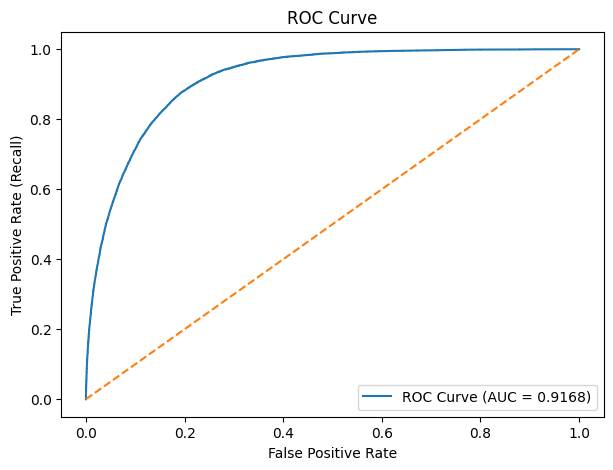

In [17]:
# probabilities
y_proba = clf.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--') 

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [18]:
y_proba = clf.predict_proba(test)[:,1]

In [19]:
value = (y_proba >= 0.25).astype(int)

In [20]:
f1_score(y_test,y_pred)

0.6847060182511262

In [21]:
df = pd.DataFrame({
    'id':test_id,
    'Churn':value
})

In [22]:
df.to_csv('sub_2.csv',index=False)